In [1]:
import pandas as pd
from localisation.localisation import Localisation
from general.helpers import Helper
from general.create_image import Animate

In [ ]:
# First get the Androo Zoo list
#archive_df = pd.read_csv("/Users/iain/Documents/projects/superapp_sprint/trackers/tracker_com.sankuai.meituan.csv")
archive_df = pd.read_csv("/Users/iain/Documents/projects/superapp_sprint/trackers/meituan_permissions.csv")
#archive_df.columns= ['sha','sha1','sha2','dexdate', 'apksize','package','?', 'virus','virusdate','!','market']
# Now to get the list of app and localisations
localised_df = pd.read_csv("/Users/iain/Documents/projects/superapp_sprint/localisation_meituan/local_found.csv")
localised_df.columns = ['sha', 'local']

In [ ]:
#merge the two together to enable sorting later. 
merged_df = pd.merge(archive_df, localised_df, on="sha")
#merged_df['language'] = merged_df['local'].map(Localisation().extract_language)
#merged_df['country'] = merged_df['local'].map(Localisation().extract_country)#
local_df = Localisation().extract_locales(merged_df)
#local_df = Helper().get_software_version(local_df, "")
local_df

In [ ]:
packages = merged_df["package"].unique()
packages

In [ ]:
for pkg in packages:
    
    tmp_df = merged_df[(merged_df["package"] == pkg) & (merged_df["country"] == "IN")]
    majors = tmp_df['major'].unique()
    for ver in majors:
        ver_df = tmp_df[tmp_df["major"] == ver]
        ver_df = ver_df.sort_values('minor')
        ver_df.to_csv("/Users/iain/Desktop/super/india/{}_{}.csv".format(pkg, ver))

In [5]:
import os
from PIL import Image

In [10]:
images = os.listdir("/Users/iain/Desktop/super/india/meituan_imgs/merchant/")
image_strings = [str("/Users/iain/Desktop/super/india/meituan_imgs/merchant/" + p) for p in images if p.endswith('png')]
img = list(sorted(set(image_strings)))

image_data = [Image.open(p) for p in img]  

<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=805x600 at 0x14DFEB760>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=805x600 at 0x152469FF0>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=805x600 at 0x152469D50>


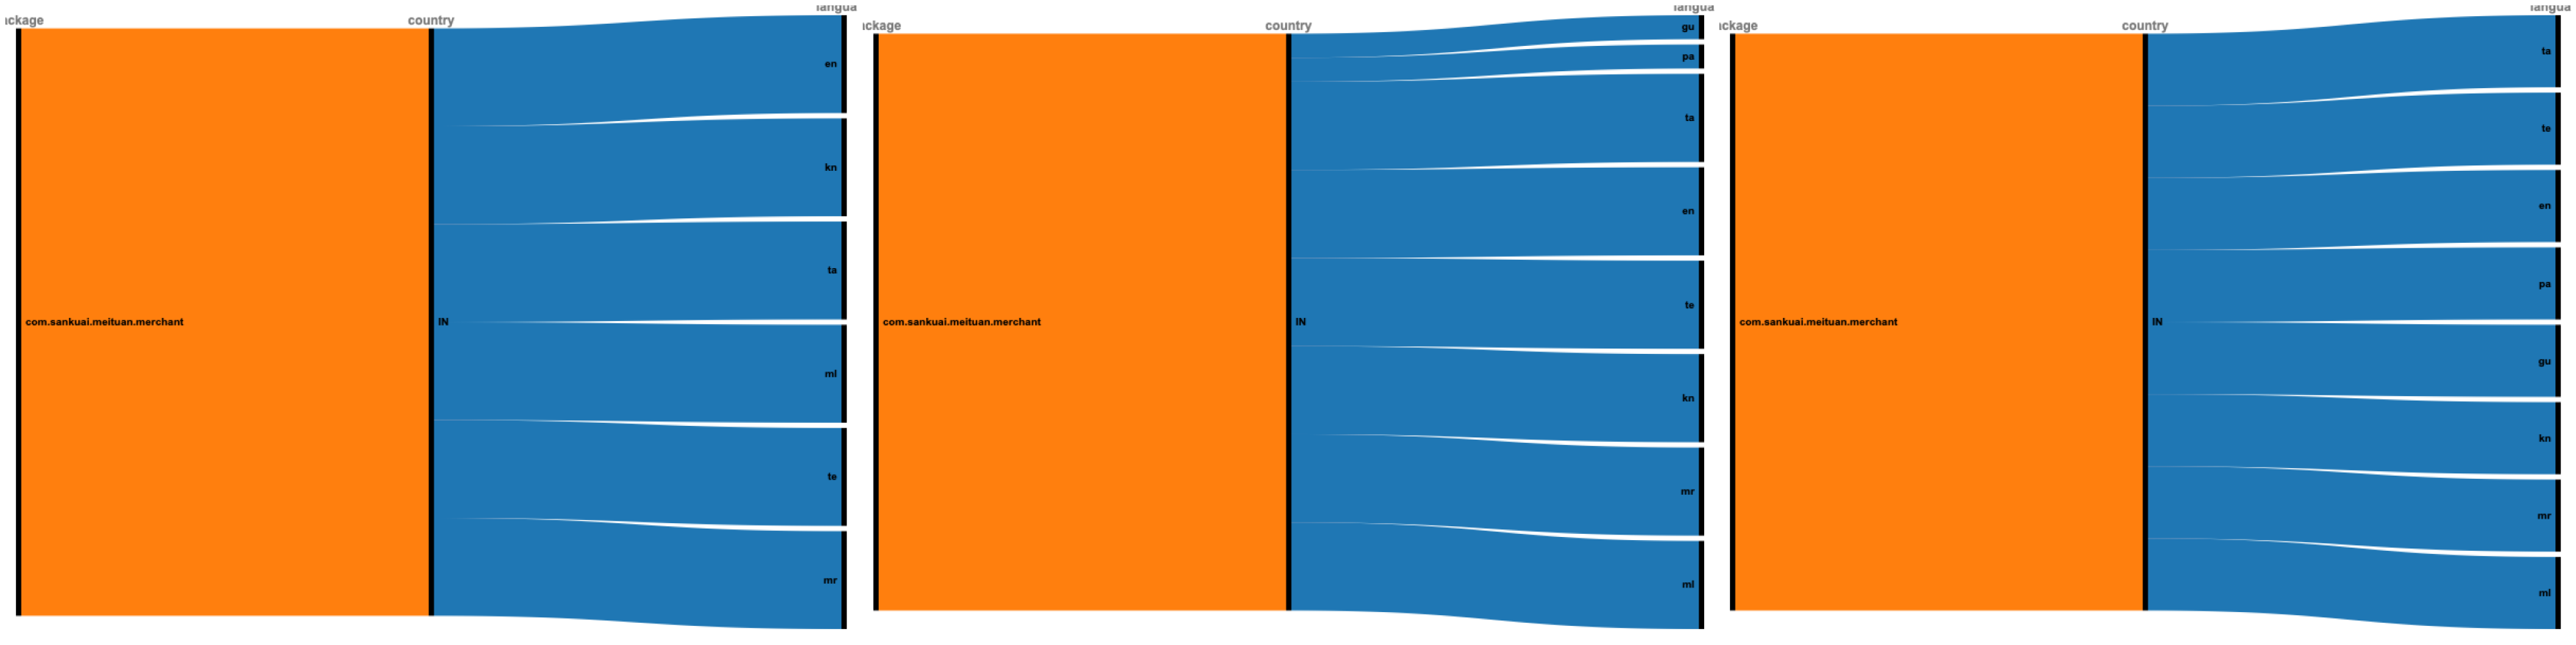

In [11]:
Animate().create_composite(image_data, "/Users/iain/Desktop/meitaun_merchant_india.png", nrow=1)